Data 2
https://www.datosabiertos.gob.pe/dataset/cobertura-de-servicio-m%C3%B3vil-por-empresa-operadora

In [ ]:
import pandas as pd

# Cargar con separador punto y coma
df2 = pd.read_csv('cobertura_movil.csv', sep=';', encoding='latin-1')

print("Filas x Columnas:", df2.shape)
print("\nPeriodos disponibles:", df2['PERIODO'].unique())
print("\nPuno con 5G:")
puno_5g = df2[(df2['DEPARTAMENTO']=='PUNO') & (df2['5G']==1)]
print(puno_5g[['EMPRESA_OPERADORA','DISTRITO','CENTRO_POBLADO','5G']])

Filas x Columnas: (21600, 25)

Periodos disponibles: [202303]

Puno con 5G:
Empty DataFrame
Columns: [EMPRESA_OPERADORA, DISTRITO, CENTRO_POBLADO, 5G]
Index: []


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cobertura_movil.csv', sep=';', encoding='latin-1')

print("Filas x Columnas:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nOperadoras:", df['EMPRESA_OPERADORA'].unique())
print("\nDepartamentos:", df['DEPARTAMENTO'].nunique(), "regiones")
df.head(3)

Filas x Columnas: (51366, 25)

Columnas: ['NUM', 'FECHA_CORTE', 'PERIODO', 'EMPRESA_OPERADORA', 'UBIGEO_CCPP', 'UBIGEO_DISTRITO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'CENTRO_POBLADO', 'LATITUD', 'LONGITUD', '2G', '3G', '4G', '5G', 'VOZ', 'SMS', 'MMS', 'HASTA_1_MBPS', 'MÁS_DE_1_MBPS', 'CANT_EB_2G', 'CANT_EB_3G', 'CANT_EB_4G', 'CANT_EB_5G']

Operadoras: ['Viettel Perú S.A.C.' 'Telefónica del Perú S.A.A.'
 'América Móvil Perú S.A.C.' 'Entel Perú S.A.']

Departamentos: 45 regiones


,NUM,FECHA_CORTE,PERIODO,EMPRESA_OPERADORA,UBIGEO_CCPP,UBIGEO_DISTRITO,DEPARTAMENTO,PROVINCIA,DISTRITO,CENTRO_POBLADO,...,5G,VOZ,SMS,MMS,HASTA_1_MBPS,MÁS_DE_1_MBPS,CANT_EB_2G,CANT_EB_3G,CANT_EB_4G,CANT_EB_5G
0,1,20230613,202303,Viettel Perú S.A.C.,101010001,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,CHACHAPOYAS,...,0,1,1,1,0,1,0,6,5,0
1,2,20230613,202303,Viettel Perú S.A.C.,101010002,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,CACLIC,...,0,1,1,1,0,1,0,0,0,0
2,3,20230613,202303,Viettel Perú S.A.C.,101010004,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,EL TAPIAL,...,0,1,1,1,0,1,0,2,2,0


In [ ]:
# Eliminar columna basura si existe
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Convertir tecnologías a numérico
for col in ['2G','3G','4G','5G']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Crear variable de brecha digital
df['tiene_4G_o_5G'] = ((df['4G']==1) | (df['5G']==1)).astype(int)
df['nivel_tecnologico'] = (
    df[['2G','3G','4G','5G']].apply(
        lambda r: '5G' if r['5G']==1
        else '4G' if r['4G']==1
        else '3G' if r['3G']==1
        else '2G' if r['2G']==1
        else 'Sin cobertura', axis=1
    )
)

print("Datos limpios")
print(df['nivel_tecnologico'].value_counts())

Datos limpios
nivel_tecnologico
4G    23022
3G    22012
2G     6302
5G       30
Name: count, dtype: int64


In [ ]:
# Calcular brecha por departamento
# Un centro poblado = una fila única (independiente de operadora)
ccpp = df.groupby(['DEPARTAMENTO','UBIGEO_CCPP']).agg(
    tiene_4G_5G = ('tiene_4G_o_5G','max'),
    max_tech = ('nivel_tecnologico', lambda x:
                '5G' if '5G' in x.values else
                '4G' if '4G' in x.values else
                '3G' if '3G' in x.values else
                '2G' if '2G' in x.values else 'Sin cobertura')
).reset_index()

brecha = ccpp.groupby('DEPARTAMENTO').agg(
    total_ccpp = ('UBIGEO_CCPP','count'),
    con_4G_5G  = ('tiene_4G_5G','sum')
).reset_index()

brecha['sin_4G_5G']   = brecha['total_ccpp'] - brecha['con_4G_5G']
brecha['pct_brecha']  = (brecha['sin_4G_5G'] / brecha['total_ccpp'] * 100).round(1)
brecha = brecha.sort_values('pct_brecha', ascending=False)

print("=== BRECHA DIGITAL POR REGIÓN ===")
print(brecha.to_string(index=False))

=== BRECHA DIGITAL POR REGIÓN ===
 DEPARTAMENTO  total_ccpp  con_4G_5G  sin_4G_5G  pct_brecha
     Arequipa           3          0          3       100.0
     Apurimac           5          0          5       100.0
     ApurImac           2          0          2       100.0
       Ancash           2          0          2       100.0
     Amazonas           2          0          2       100.0
     Ayacucho           4          0          4       100.0
     Moquegua           2          0          2       100.0
   Lambayeque           1          0          1       100.0
         Lima          13          0         13       100.0
        Junin           5          0          5       100.0
 Huancavelica           4          0          4       100.0
        Cusco           3          0          3       100.0
    Cajamarca           2          0          2       100.0
         Puno           5          0          5       100.0
   San Martin           1          0          1       100.0
      

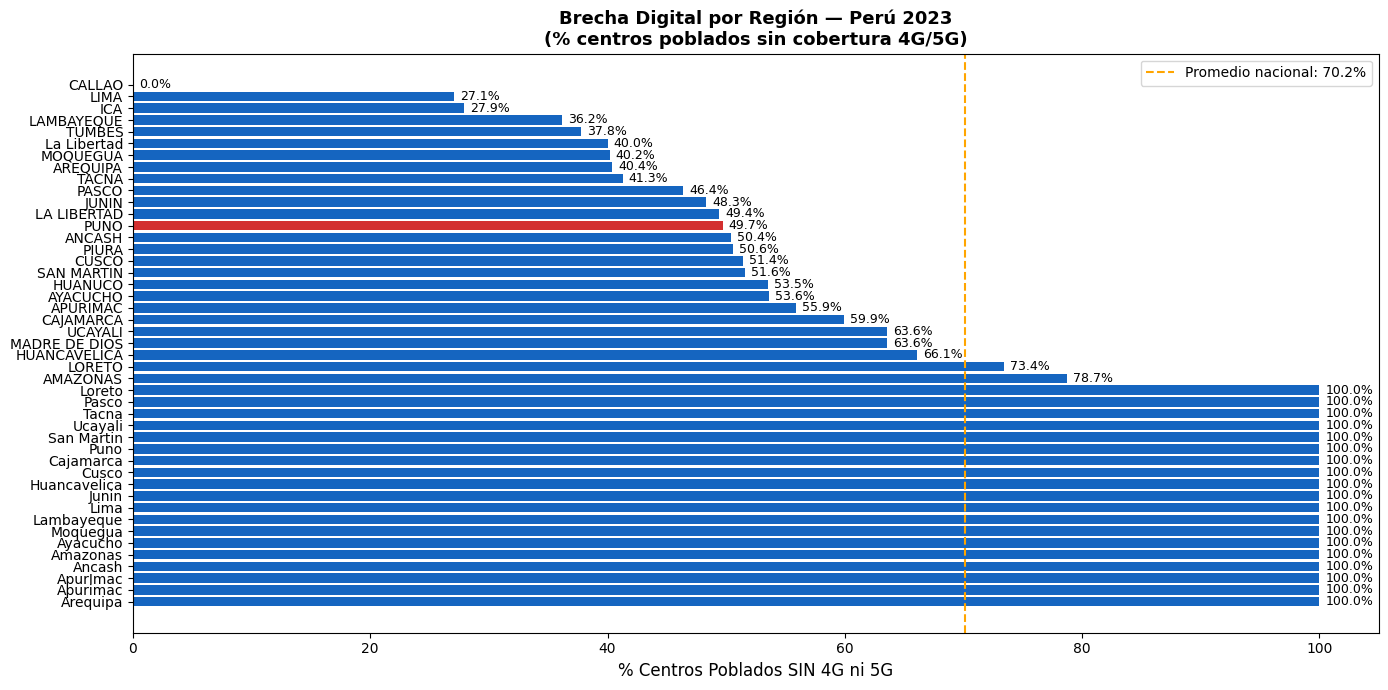

Gráfico guardado


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

colores = ['#d32f2f' if d == 'PUNO' else '#1565C0' for d in brecha['DEPARTAMENTO']]

bars = ax.barh(brecha['DEPARTAMENTO'], brecha['pct_brecha'], color=colores)

# Etiquetas de valor
for bar, val in zip(bars, brecha['pct_brecha']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('% Centros Poblados SIN 4G ni 5G', fontsize=12)
ax.set_title('Brecha Digital por Región — Perú 2023\n(% centros poblados sin cobertura 4G/5G)',
             fontsize=13, fontweight='bold')
ax.axvline(x=brecha['pct_brecha'].mean(), color='orange',
           linestyle='--', label=f"Promedio nacional: {brecha['pct_brecha'].mean():.1f}%")
ax.legend()
plt.tight_layout()
plt.savefig('brecha_digital_peru.png', dpi=150)
plt.show()
print("Gráfico guardado")

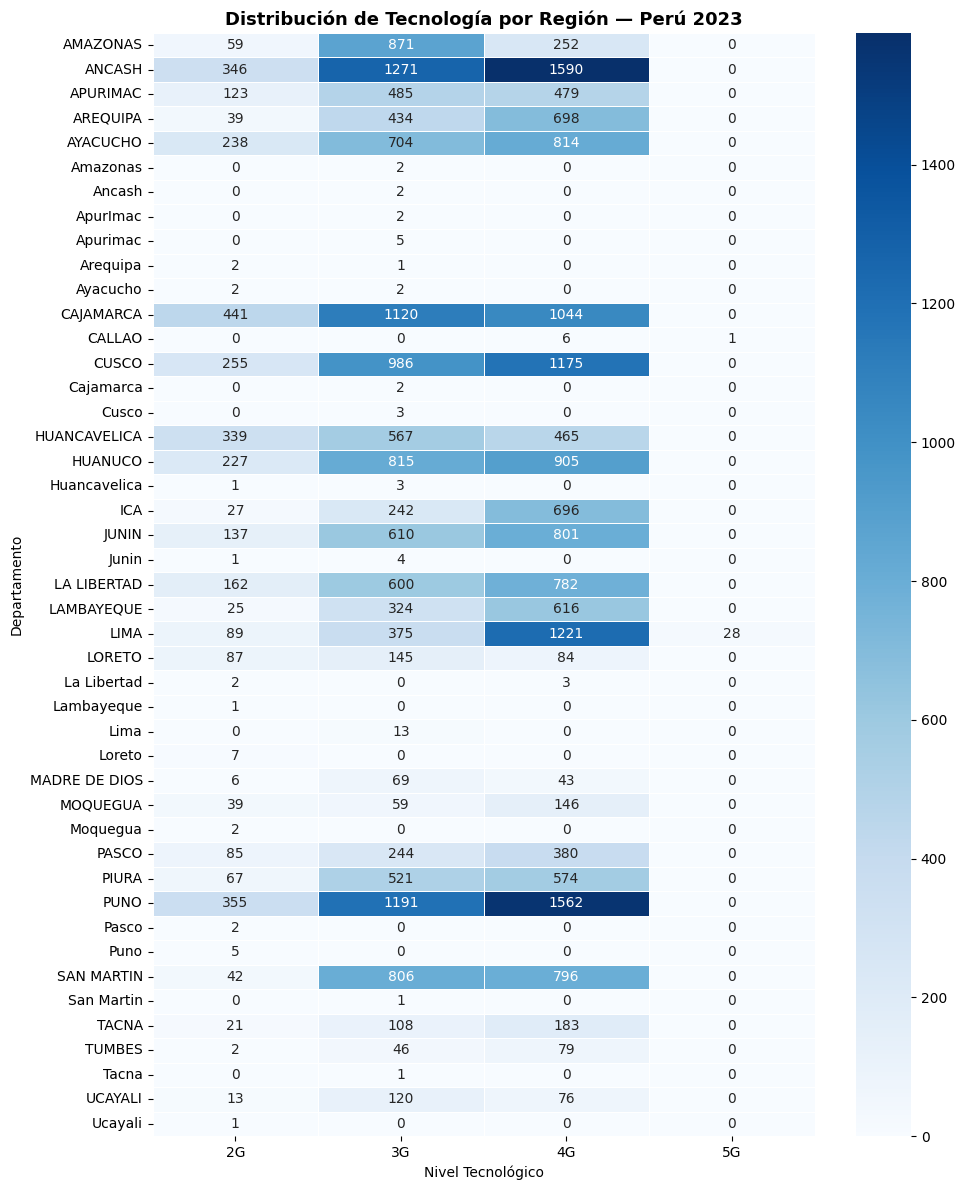

In [ ]:
pivot = ccpp.groupby(['DEPARTAMENTO','max_tech']).size().unstack(fill_value=0)
orden = ['Sin cobertura','2G','3G','4G','5G']
pivot = pivot.reindex(columns=[c for c in orden if c in pivot.columns])

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Distribución de Tecnología por Región — Perú 2023',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel Tecnológico')
ax.set_ylabel('Departamento')
plt.tight_layout()
plt.savefig('heatmap_tecnologia.png', dpi=150)
plt.show()

=== COBERTURA POR OPERADORA ===
                            ccpp_cubiertos  con_4G  con_5G
EMPRESA_OPERADORA                                         
Viettel Perú S.A.C.                  24157   11392       0
Telefónica del Perú S.A.A.           14715    5065       0
América Móvil Perú S.A.C.             6351    3449      28
Entel Perú S.A.                       6143    3142       2


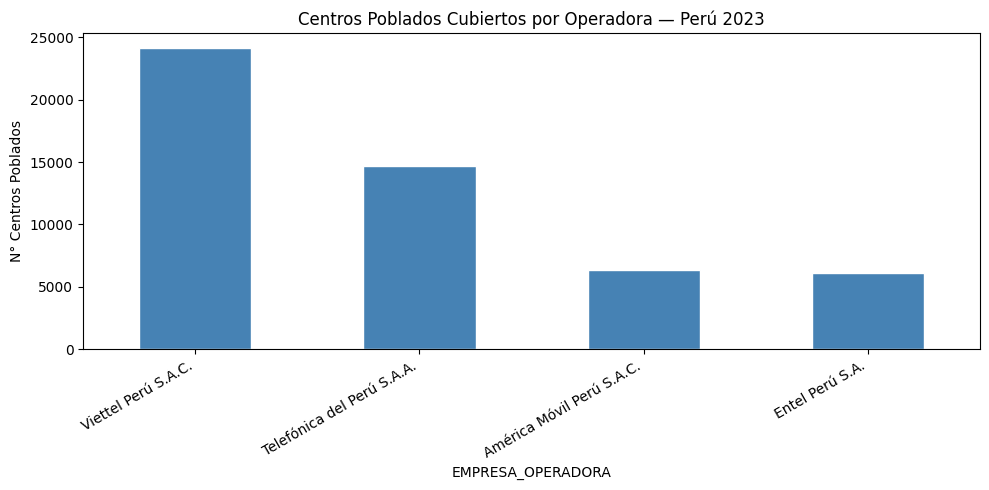

In [ ]:
op = df.groupby('EMPRESA_OPERADORA').agg(
    ccpp_cubiertos = ('UBIGEO_CCPP','nunique'),
    con_4G = ('4G','sum'),
    con_5G = ('5G','sum')
).sort_values('ccpp_cubiertos', ascending=False)

print("=== COBERTURA POR OPERADORA ===")
print(op)

op['ccpp_cubiertos'].plot(kind='bar', figsize=(10,5),
                          color='steelblue', edgecolor='white')
plt.title('Centros Poblados Cubiertos por Operadora — Perú 2023')
plt.ylabel('N° Centros Poblados')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('cobertura_operadora.png', dpi=150)
plt.show()

In [ ]:
puno = ccpp[ccpp['DEPARTAMENTO']=='PUNO']

print(f"Total centros poblados en PUNO: {len(puno)}")
print(f"Con 4G o 5G: {puno['tiene_4G_5G'].sum()}")
print(f"Sin 4G ni 5G: {(puno['tiene_4G_5G']==0).sum()}")
print(f"% Brecha en PUNO: {(puno['tiene_4G_5G']==0).mean()*100:.1f}%")
print(f"\nDistribución tecnológica en PUNO:")
print(puno['max_tech'].value_counts())

Total centros poblados en PUNO: 3108
Con 4G o 5G: 1562
Sin 4G ni 5G: 1546
% Brecha en PUNO: 49.7%

Distribución tecnológica en PUNO:
max_tech
4G    1562
3G    1191
2G     355
Name: count, dtype: int64


Hipotesis


=== BRECHA DIGITAL POR ZONA GEOGRÁFICA ===
        promedio_brecha  total_ccpp  sin_4G_5G
zona                                          
Costa              35.1        8210       3180
Selva              66.2        3469       2218
Sierra             53.5       19754      10539


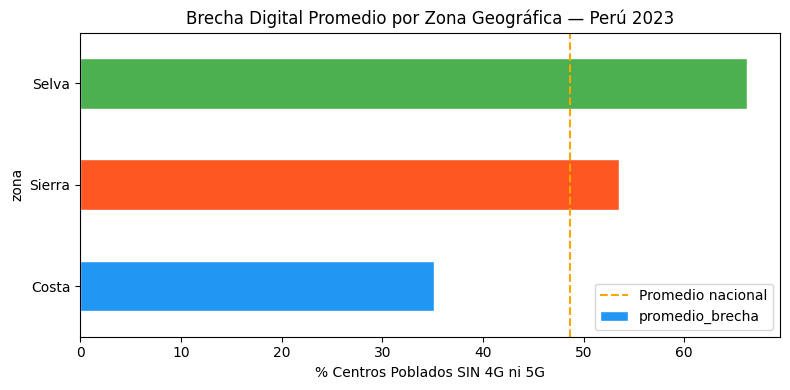

In [ ]:
# Clasificar regiones por tipo geográfico
costa   = ['LIMA','CALLAO','ICA','LAMBAYEQUE','LA LIBERTAD',
           'PIURA','TUMBES','AREQUIPA','MOQUEGUA','TACNA']
sierra  = ['PUNO','CUSCO','JUNIN','ANCASH','CAJAMARCA',
           'AYACUCHO','APURIMAC','HUANCAVELICA','PASCO','HUANUCO']
selva   = ['LORETO','UCAYALI','AMAZONAS','SAN MARTIN',
           'MADRE DE DIOS']

def zona(dep):
    if dep in costa:  return 'Costa'
    if dep in sierra: return 'Sierra'
    if dep in selva:  return 'Selva'
    return 'Otro'

brecha['zona'] = brecha['DEPARTAMENTO'].apply(zona)
brecha_valida  = brecha[brecha['zona'] != 'Otro']

resumen_zona = brecha_valida.groupby('zona').agg(
    promedio_brecha = ('pct_brecha','mean'),
    total_ccpp      = ('total_ccpp','sum'),
    sin_4G_5G       = ('sin_4G_5G','sum')
).round(1)

print("=== BRECHA DIGITAL POR ZONA GEOGRÁFICA ===")
print(resumen_zona)

# Gráfico
resumen_zona['promedio_brecha'].sort_values().plot(
    kind='barh', color=['#2196F3','#FF5722','#4CAF50'],
    figsize=(8,4), edgecolor='white'
)
plt.title('Brecha Digital Promedio por Zona Geográfica — Perú 2023')
plt.xlabel('% Centros Poblados SIN 4G ni 5G')
plt.axvline(x=brecha_valida['pct_brecha'].mean(),
            color='orange', linestyle='--', label='Promedio nacional')
plt.legend()
plt.tight_layout()
plt.savefig('brecha_por_zona.png', dpi=150)
plt.show()

=== % DE COBERTURA POR TECNOLOGÍA Y OPERADORA ===
                              2G    3G    4G   5G
EMPRESA_OPERADORA                                
América Móvil Perú S.A.C.    0.4  63.8  35.5  0.3
Entel Perú S.A.              5.1  43.7  51.1  0.0
Telefónica del Perú S.A.A.  40.6  25.1  34.3  0.0
Viettel Perú S.A.C.          0.0  66.8  33.2  0.0


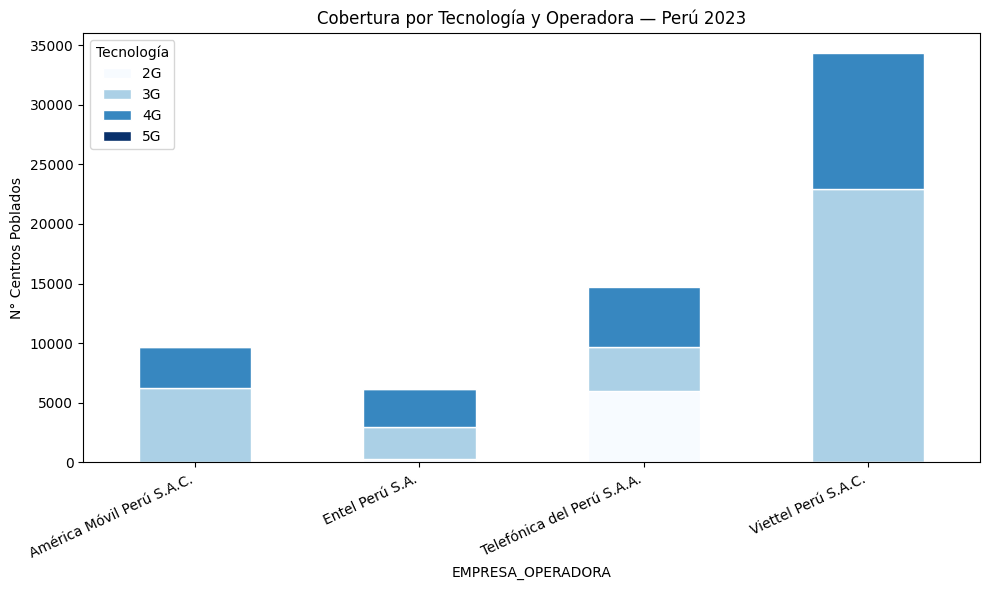

In [ ]:
# Cobertura por operadora Y por tecnología
op_tech = df.groupby('EMPRESA_OPERADORA')[['2G','3G','4G','5G']].sum()
op_tech_pct = op_tech.div(op_tech.sum(axis=1), axis=0) * 100

print("=== % DE COBERTURA POR TECNOLOGÍA Y OPERADORA ===")
print(op_tech_pct.round(1))

# Gráfico apilado
op_tech.plot(kind='bar', stacked=True, figsize=(10,6),
             colormap='Blues', edgecolor='white')
plt.title('Cobertura por Tecnología y Operadora — Perú 2023')
plt.ylabel('N° Centros Poblados')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Tecnología')
plt.tight_layout()
plt.savefig('operadora_tecnologia.png', dpi=150)
plt.show()

=== PUNO vs PROMEDIO NACIONAL ===
Cobertura 4G/5G nacional:  49.2%
Cobertura 4G/5G en PUNO:   50.3%
Diferencia:                --1.1 puntos porcentuales

Puno vs otras regiones:
Puno ocupa el puesto 12 de 25 regiones en cobertura 4G/5G


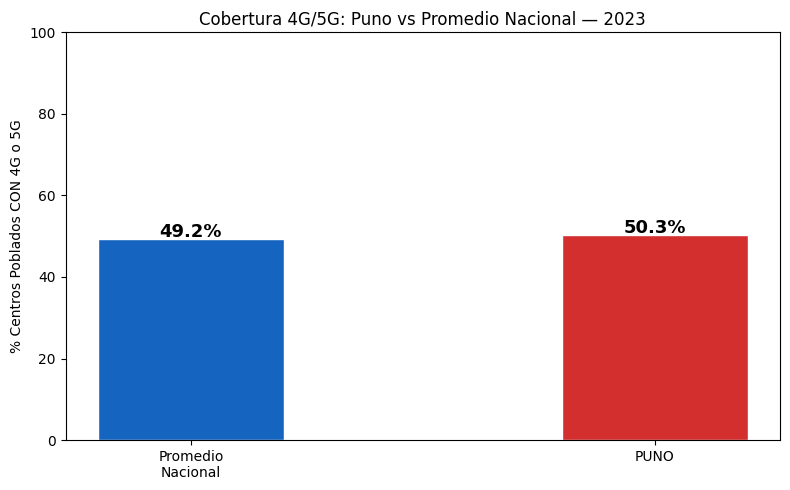

In [ ]:
# Puno vs promedio nacional
nacional_4G = ccpp['tiene_4G_5G'].mean() * 100
puno_4G     = ccpp[ccpp['DEPARTAMENTO']=='PUNO']['tiene_4G_5G'].mean() * 100

print("=== PUNO vs PROMEDIO NACIONAL ===")
print(f"Cobertura 4G/5G nacional:  {nacional_4G:.1f}%")
print(f"Cobertura 4G/5G en PUNO:   {puno_4G:.1f}%")
print(f"Diferencia:                -{nacional_4G - puno_4G:.1f} puntos porcentuales")
print(f"\nPuno vs otras regiones:")
ranking = ccpp.groupby('DEPARTAMENTO')['tiene_4G_5G'].mean().sort_values(ascending=False)*100
ranking = ranking[ranking.index.isin(costa+sierra+selva)]
posicion = list(ranking.index).index('PUNO') + 1
print(f"Puno ocupa el puesto {posicion} de {len(ranking)} regiones en cobertura 4G/5G")

# Gráfico comparativo Puno vs Nacional
fig, ax = plt.subplots(figsize=(8,5))
categorias = ['Promedio\nNacional', 'PUNO']
valores    = [nacional_4G, puno_4G]
colores    = ['#1565C0','#d32f2f']
bars = ax.bar(categorias, valores, color=colores, width=0.4, edgecolor='white')
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel('% Centros Poblados CON 4G o 5G')
ax.set_title('Cobertura 4G/5G: Puno vs Promedio Nacional — 2023')
plt.tight_layout()
plt.savefig('puno_vs_nacional.png', dpi=150)
plt.show()

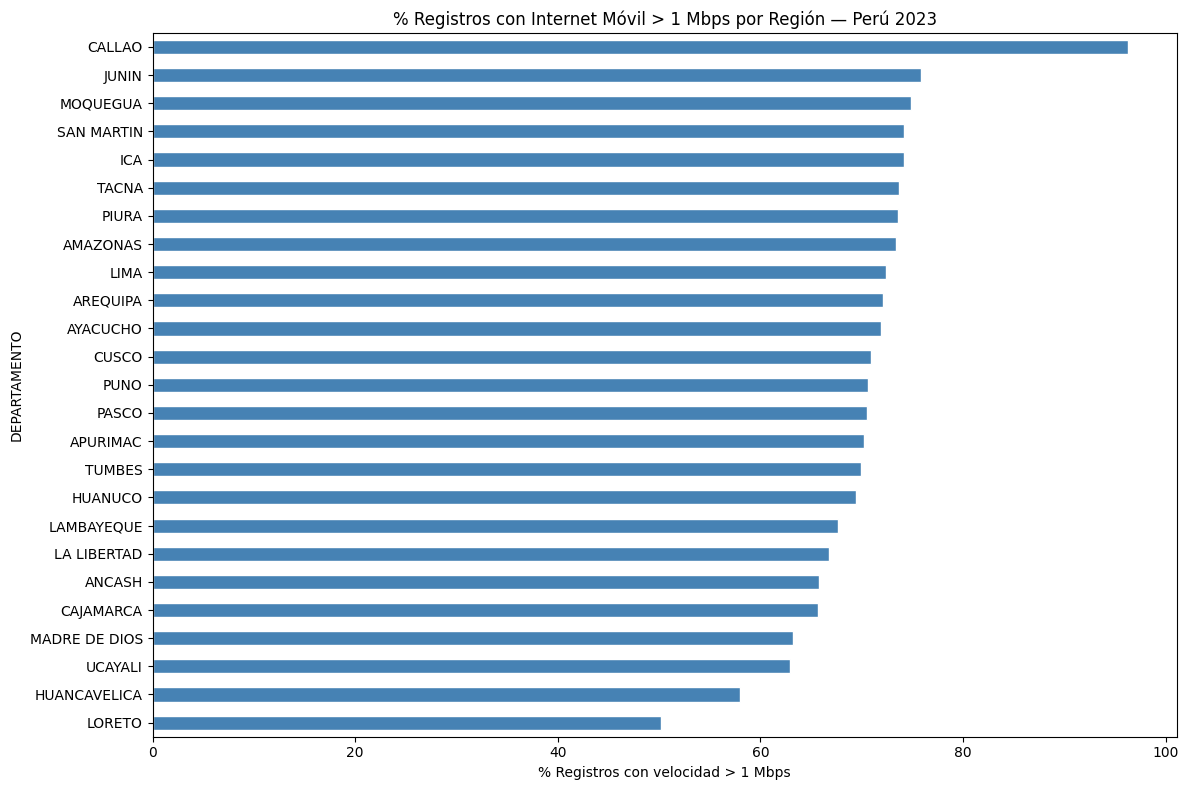

In [ ]:
# Análisis de velocidad de internet móvil por región
vel = df.groupby('DEPARTAMENTO').agg(
    con_mas_1mbps  = ('MÁS_DE_1_MBPS','sum'),
    total          = ('UBIGEO_CCPP','count')
).reset_index()
vel['pct_velocidad'] = (vel['con_mas_1mbps'] / vel['total'] * 100).round(1)
vel = vel[vel['DEPARTAMENTO'].isin(costa+sierra+selva)]
vel = vel.sort_values('pct_velocidad', ascending=True)

vel.set_index('DEPARTAMENTO')['pct_velocidad'].plot(
    kind='barh', figsize=(12,8), color='steelblue', edgecolor='white'
)
plt.title('% Registros con Internet Móvil > 1 Mbps por Región — Perú 2023')
plt.xlabel('% Registros con velocidad > 1 Mbps')
plt.tight_layout()
plt.savefig('velocidad_region.png', dpi=150)
plt.show()

Hipoteiss 2

In [ ]:
costa   = ['LIMA','CALLAO','ICA','LAMBAYEQUE','LA LIBERTAD',
           'PIURA','TUMBES','AREQUIPA','MOQUEGUA','TACNA']
sierra  = ['PUNO','CUSCO','JUNIN','ANCASH','CAJAMARCA',
           'AYACUCHO','APURIMAC','HUANCAVELICA','PASCO','HUANUCO']
selva   = ['LORETO','UCAYALI','AMAZONAS','SAN MARTIN',
           'MADRE DE DIOS']

def zona(dep):
    if dep in costa:  return 'Costa'
    if dep in sierra: return 'Sierra'
    if dep in selva:  return 'Selva'
    return 'Otro'

brecha['zona'] = brecha['DEPARTAMENTO'].apply(zona)
brecha_valida  = brecha[brecha['zona'] != 'Otro']

resumen_zona = brecha_valida.groupby('zona').agg(
    promedio_brecha = ('pct_brecha','mean'),
    total_ccpp      = ('total_ccpp','sum'),
    sin_4G_5G       = ('sin_4G_5G','sum')
).round(1)

print("=== BRECHA POR ZONA GEOGRÁFICA ===")
print(resumen_zona)

=== BRECHA POR ZONA GEOGRÁFICA ===
        promedio_brecha  total_ccpp  sin_4G_5G
zona                                          
Costa              35.1        8210       3180
Selva              66.2        3469       2218
Sierra             53.5       19754      10539


In [ ]:
op_tech = df.groupby('EMPRESA_OPERADORA')[['2G','3G','4G','5G']].sum()
op_tech_pct = op_tech.div(op_tech.sum(axis=1), axis=0) * 100
print("=== % COBERTURA POR TECNOLOGÍA Y OPERADORA ===")
print(op_tech_pct.round(1))
print("\n=== TOTALES ABSOLUTOS ===")
print(op_tech)

=== % COBERTURA POR TECNOLOGÍA Y OPERADORA ===
                              2G    3G    4G   5G
EMPRESA_OPERADORA                                
América Móvil Perú S.A.C.    0.4  63.8  35.5  0.3
Entel Perú S.A.              5.1  43.7  51.1  0.0
Telefónica del Perú S.A.A.  40.6  25.1  34.3  0.0
Viettel Perú S.A.C.          0.0  66.8  33.2  0.0

=== TOTALES ABSOLUTOS ===
                              2G     3G     4G  5G
EMPRESA_OPERADORA                                 
América Móvil Perú S.A.C.     41   6201   3449  28
Entel Perú S.A.              313   2688   3142   2
Telefónica del Perú S.A.A.  5987   3702   5065   0
Viettel Perú S.A.C.            0  22918  11392   0


In [ ]:
nacional_4G = ccpp['tiene_4G_5G'].mean() * 100
puno_4G     = ccpp[ccpp['DEPARTAMENTO']=='PUNO']['tiene_4G_5G'].mean() * 100
ranking = ccpp.groupby('DEPARTAMENTO')['tiene_4G_5G'].mean().sort_values(ascending=False)*100
ranking_valido = ranking[ranking.index.isin(costa+sierra+selva)]
posicion = list(ranking_valido.index).index('PUNO') + 1

print(f"Cobertura 4G/5G nacional:    {nacional_4G:.1f}%")
print(f"Cobertura 4G/5G PUNO:        {puno_4G:.1f}%")
print(f"Diferencia:                  -{nacional_4G - puno_4G:.1f} pts")
print(f"Puno ocupa puesto:           {posicion} de {len(ranking_valido)}")
print(f"\n=== RANKING COMPLETO ===")
print(ranking_valido.round(1))

Cobertura 4G/5G nacional:    49.2%
Cobertura 4G/5G PUNO:        50.3%
Diferencia:                  --1.1 pts
Puno ocupa puesto:           12 de 25

=== RANKING COMPLETO ===
DEPARTAMENTO
CALLAO           100.0
LIMA              72.9
ICA               72.1
LAMBAYEQUE        63.8
TUMBES            62.2
MOQUEGUA          59.8
AREQUIPA          59.6
TACNA             58.7
PASCO             53.6
JUNIN             51.7
LA LIBERTAD       50.6
PUNO              50.3
ANCASH            49.6
PIURA             49.4
CUSCO             48.6
SAN MARTIN        48.4
HUANUCO           46.5
AYACUCHO          46.4
APURIMAC          44.1
CAJAMARCA         40.1
MADRE DE DIOS     36.4
UCAYALI           36.4
HUANCAVELICA      33.9
LORETO            26.6
AMAZONAS          21.3
Name: tiene_4G_5G, dtype: float64


In [ ]:
print("=== SERVICIOS DISPONIBLES A NIVEL NACIONAL ===")
servicios = ['VOZ','SMS','MMS','HASTA_1_MBPS','MÁS_DE_1_MBPS']
for s in servicios:
    pct = df[s].mean()*100
    print(f"{s:20s}: {pct:.1f}%")

print("\n=== VELOCIDAD >1MBPS POR ZONA ===")
df['zona'] = df['DEPARTAMENTO'].apply(zona)
vel_zona = df[df['zona']!='Otro'].groupby('zona')['MÁS_DE_1_MBPS'].mean()*100
print(vel_zona.round(1))

print("\n=== TOTAL CCPP ÚNICOS CON ALGUNA COBERTURA ===")
print(f"Total centros poblados con cobertura: {df['UBIGEO_CCPP'].nunique():,}")
print(f"Total registros dataset:              {len(df):,}")

=== SERVICIOS DISPONIBLES A NIVEL NACIONAL ===
VOZ                 : 97.4%
SMS                 : 95.0%
MMS                 : 70.2%
HASTA_1_MBPS        : 21.6%
MÁS_DE_1_MBPS       : 69.7%

=== VELOCIDAD >1MBPS POR ZONA ===
zona
Costa     71.3
Selva     70.8
Sierra    68.8
Name: MÁS_DE_1_MBPS, dtype: float64

=== TOTAL CCPP ÚNICOS CON ALGUNA COBERTURA ===
Total centros poblados con cobertura: 31,439
Total registros dataset:              51,366


In [ ]:
print("====== RESUMEN EJECUTIVO PARA TESIS ======")
print(f"\nDATOS GENERALES:")
print(f"   Total registros analizados:     {len(df):,}")
print(f"   Centros poblados únicos:        {df['UBIGEO_CCPP'].nunique():,}")
print(f"   Regiones analizadas:            25")
print(f"   Empresas operadoras:            {df['EMPRESA_OPERADORA'].nunique()}")
print(f"   Periodo:                        Marzo 2023 (202303)")

print(f"\n COBERTURA TECNOLÓGICA:")
for tech in ['2G','3G','4G','5G']:
    n = (df[tech]==1).sum()
    pct = (df[tech]==1).mean()*100
    print(f"   {tech}: {n:,} registros ({pct:.1f}%)")

print(f"\n BRECHA DIGITAL NACIONAL:")
print(f"   CCPP SIN 4G ni 5G:  {brecha_valida['sin_4G_5G'].sum():,}")
print(f"   CCPP CON 4G o 5G:   {brecha_valida['con_4G_5G'].sum():,}")
print(f"   % Brecha nacional:  {brecha_valida['pct_brecha'].mean():.1f}%")

print(f"\n PUNO:")
print(f"   Total CCPP:         {len(ccpp[ccpp['DEPARTAMENTO']=='PUNO']):,}")
print(f"   Con 4G/5G:          {ccpp[ccpp['DEPARTAMENTO']=='PUNO']['tiene_4G_5G'].sum():,}")
print(f"   Sin 4G/5G:          {(ccpp[ccpp['DEPARTAMENTO']=='PUNO']['tiene_4G_5G']==0).sum():,}")
print(f"   % Brecha Puno:      {(1 - puno_4G/100)*100:.1f}%")

====== RESUMEN EJECUTIVO PARA TESIS ======

DATOS GENERALES:
   Total registros analizados:     51,366
   Centros poblados únicos:        31,439
   Regiones analizadas:            25
   Empresas operadoras:            4
   Periodo:                        Marzo 2023 (202303)

 COBERTURA TECNOLÓGICA:
   2G: 6,341 registros (12.3%)
   3G: 35,509 registros (69.1%)
   4G: 23,048 registros (44.9%)
   5G: 30 registros (0.1%)

 BRECHA DIGITAL NACIONAL:
   CCPP SIN 4G ni 5G:  15,937
   CCPP CON 4G o 5G:   15,496
   % Brecha nacional:  48.7%

 PUNO:
   Total CCPP:         3,108
   Con 4G/5G:          1,562
   Sin 4G/5G:          1,546
   % Brecha Puno:      49.7%


=========

In [ ]:
from scipy.stats import chi2_contingency, kruskal
import numpy as np

# Tabla de contingencia: zona vs tiene_4G_5G
ccpp['zona'] = ccpp['DEPARTAMENTO'].apply(zona)
ccpp_valido  = ccpp[ccpp['zona'] != 'Otro']

tabla_chi2 = pd.crosstab(ccpp_valido['zona'], ccpp_valido['tiene_4G_5G'])
print("=== TABLA DE CONTINGENCIA ===")
print(tabla_chi2)
print("\nColumnas: 0=Sin 4G/5G  |  1=Con 4G/5G")

chi2, p, dof, expected = chi2_contingency(tabla_chi2)
print(f"\n=== PRUEBA CHI-CUADRADO ===")
print(f"Chi2 estadístico : {chi2:.4f}")
print(f"Valor p          : {p:.6f}")
print(f"Grados de libertad: {dof}")
print(f"\n{'SE RECHAZA H0' if p < 0.05 else '❌ NO se rechaza H0'} (α=0.05)")
print("→ Hay asociación significativa entre zona geográfica y cobertura 4G/5G" if p < 0.05 else "→ No hay asociación significativa")

=== TABLA DE CONTINGENCIA ===
tiene_4G_5G      0     1
zona                    
Costa         3180  5030
Selva         2218  1251
Sierra       10539  9215

Columnas: 0=Sin 4G/5G  |  1=Con 4G/5G

=== PRUEBA CHI-CUADRADO ===
Chi2 estadístico : 769.1300
Valor p          : 0.000000
Grados de libertad: 2

SE RECHAZA H0 (α=0.05)
→ Hay asociación significativa entre zona geográfica y cobertura 4G/5G


In [ ]:
# Separar grupos por zona
costa_vals  = brecha_valida[brecha_valida['zona']=='Costa']['pct_brecha']
sierra_vals = brecha_valida[brecha_valida['zona']=='Sierra']['pct_brecha']
selva_vals  = brecha_valida[brecha_valida['zona']=='Selva']['pct_brecha']

stat, p_kw = kruskal(costa_vals, sierra_vals, selva_vals)

print("=== PRUEBA KRUSKAL-WALLIS ===")
print(f"Estadístico H  : {stat:.4f}")
print(f"Valor p        : {p_kw:.6f}")
print(f"\n{' SE RECHAZA H0' if p_kw < 0.05 else '❌ NO se rechaza H0'} (α=0.05)")
print("→ Existen diferencias significativas en brecha digital entre zonas" if p_kw < 0.05 else "→ No hay diferencias significativas")

print(f"\n=== MEDIAS POR ZONA ===")
print(f"Costa  : {costa_vals.mean():.1f}%  (n={len(costa_vals)})")
print(f"Sierra : {sierra_vals.mean():.1f}%  (n={len(sierra_vals)})")
print(f"Selva  : {selva_vals.mean():.1f}%  (n={len(selva_vals)})")

# Post-hoc: comparación por pares (Mann-Whitney)
from scipy.stats import mannwhitneyu
print("\n=== POST-HOC MANN-WHITNEY (comparación por pares) ===")
pares = [('Costa','Sierra'), ('Costa','Selva'), ('Sierra','Selva')]
grupos = {'Costa': costa_vals, 'Sierra': sierra_vals, 'Selva': selva_vals}
for a, b in pares:
    u, p_mw = mannwhitneyu(grupos[a], grupos[b], alternative='two-sided')
    sig = 'Significativo' if p_mw < 0.05 else '❌ No significativo'
    print(f"{a} vs {b}: U={u:.1f}, p={p_mw:.4f} → {sig}")

=== PRUEBA KRUSKAL-WALLIS ===
Estadístico H  : 16.8711
Valor p        : 0.000217

 SE RECHAZA H0 (α=0.05)
→ Existen diferencias significativas en brecha digital entre zonas

=== MEDIAS POR ZONA ===
Costa  : 35.1%  (n=10)
Sierra : 53.5%  (n=10)
Selva  : 66.2%  (n=5)

=== POST-HOC MANN-WHITNEY (comparación por pares) ===
Costa vs Sierra: U=6.0, p=0.0010 → Significativo
Costa vs Selva: U=0.0, p=0.0027 → Significativo
Sierra vs Selva: U=7.0, p=0.0319 → Significativo


In [ ]:
from scipy.stats import chi2_contingency

# Tabla: operadora vs tiene_4G
tabla_op = pd.crosstab(df['EMPRESA_OPERADORA'], df['4G'])
chi2_op, p_op, dof_op, _ = chi2_contingency(tabla_op)

print("=== PRUEBA CHI² — OPERADORA vs COBERTURA 4G ===")
print(f"Chi2: {chi2_op:.4f} | p: {p_op:.6f} | gl: {dof_op}")
print(f"{' Diferencia significativa entre operadoras' if p_op < 0.05 else '❌ No hay diferencia significativa'}")

# Índice de concentración — Herfindahl
op_share = df.groupby('EMPRESA_OPERADORA')['UBIGEO_CCPP'].nunique()
total    = op_share.sum()
hhi      = ((op_share / total) ** 2).sum() * 10000
print(f"\n=== ÍNDICE HHI DE CONCENTRACIÓN DE MERCADO ===")
print(op_share)
print(f"\nHHI = {hhi:.0f}")
print("Interpretación:",
      "Concentrado (>2500)" if hhi > 2500 else
      "Moderado (1500-2500)" if hhi > 1500 else
      "Competitivo (<1500)")

=== PRUEBA CHI² — OPERADORA vs COBERTURA 4G ===
Chi2: 1027.1359 | p: 0.000000 | gl: 3
 Diferencia significativa entre operadoras

=== ÍNDICE HHI DE CONCENTRACIÓN DE MERCADO ===
EMPRESA_OPERADORA
América Móvil Perú S.A.C.      6351
Entel Perú S.A.                6143
Telefónica del Perú S.A.A.    14715
Viettel Perú S.A.C.           24157
Name: UBIGEO_CCPP, dtype: int64

HHI = 3328
Interpretación: Concentrado (>2500)


In [ ]:
# Instalar folium si no está
!pip install folium -q

In [ ]:
import folium
from folium.plugins import HeatMap

# Preparar data con coordenadas — centros poblados sin 4G/5G
df_geo = df[['DEPARTAMENTO','CENTRO_POBLADO','LATITUD','LONGITUD','4G','5G']].copy()
df_geo = df_geo.dropna(subset=['LATITUD','LONGITUD'])
df_geo['sin_4G_5G'] = ((df_geo['4G']==0) & (df_geo['5G']==0)).astype(int)

# Filtrar: solo sin cobertura 4G/5G
sin_cobertura = df_geo[df_geo['sin_4G_5G']==1][['LATITUD','LONGITUD']]
print(f"Puntos para mapa de calor: {len(sin_cobertura):,}")

# Crear mapa centrado en Perú
mapa = folium.Map(location=[-9.19, -75.015], zoom_start=6,
                  tiles='CartoDB dark_matter')

# Capa de calor — zonas sin cobertura 4G/5G
HeatMap(
    sin_cobertura[['LATITUD','LONGITUD']].values.tolist(),
    radius=8, blur=10, max_zoom=8,
    gradient={'0.2':'blue','0.4':'cyan','0.6':'yellow','0.8':'orange','1.0':'red'}
).add_to(mapa)

# Título
titulo = """
<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
background:rgba(0,0,0,0.7);color:white;padding:10px 20px;
border-radius:8px;font-size:14px;z-index:1000;">
Mapa de Calor — Brecha Digital 4G/5G en Perú (2023)
</div>"""
mapa.get_root().html.add_child(folium.Element(titulo))

# Guardar
mapa.save('mapa_brecha_digital.html')
print(" Mapa guardado: mapa_brecha_digital.html")
mapa

Puntos para mapa de calor: 28,314
 Mapa guardado: mapa_brecha_digital.html


In [ ]:
# Mapa con círculos proporcionales a la brecha por región
mapa2 = folium.Map(location=[-9.19, -75.015], zoom_start=6,
                   tiles='CartoDB positron')

# Coordenadas aproximadas de capitales regionales
coords_regiones = {
    'AMAZONAS':(-6.23,-77.87),'ANCASH':(-9.53,-77.53),
    'APURIMAC':(-13.63,-72.88),'AREQUIPA':(-16.40,-71.54),
    'AYACUCHO':(-13.16,-74.22),'CAJAMARCA':(-7.16,-78.51),
    'CALLAO':(-12.05,-77.12),'CUSCO':(-13.53,-71.97),
    'HUANCAVELICA':(-12.78,-74.97),'HUANUCO':(-9.93,-76.24),
    'ICA':(-14.07,-75.73),'JUNIN':(-12.06,-75.20),
    'LA LIBERTAD':(-8.11,-79.03),'LAMBAYEQUE':(-6.77,-79.84),
    'LIMA':(-12.04,-77.03),'LORETO':(-3.75,-73.25),
    'MADRE DE DIOS':(-12.59,-69.19),'MOQUEGUA':(-17.19,-70.93),
    'PASCO':(-10.69,-76.26),'PIURA':(-5.19,-80.63),
    'PUNO':(-15.84,-70.02),'SAN MARTIN':(-6.49,-76.37),
    'TACNA':(-18.01,-70.25),'TUMBES':(-3.57,-80.45),
    'UCAYALI':(-8.39,-74.55)
}

for _, row in brecha_valida.iterrows():
    dep = row['DEPARTAMENTO']
    if dep not in coords_regiones: continue
    lat, lon = coords_regiones[dep]
    pct      = row['pct_brecha']
    color    = '#d32f2f' if pct > 60 else '#FF9800' if pct > 40 else '#4CAF50'

    folium.CircleMarker(
        location=[lat, lon],
        radius=max(5, pct/4),
        color=color, fill=True, fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{dep}</b><br>Brecha: {pct}%<br>"
            f"CCPP sin 4G/5G: {int(row['sin_4G_5G']):,}<br>"
            f"Total CCPP: {int(row['total_ccpp']):,}",
            max_width=200
        ),
        tooltip=f"{dep}: {pct}%"
    ).add_to(mapa2)

# Leyenda
leyenda = """
<div style="position:fixed;bottom:30px;right:10px;
background:white;padding:10px;border-radius:8px;
border:2px solid grey;font-size:12px;z-index:1000;">
<b>Brecha Digital</b><br>
🔴 &gt;60% Alta<br>
🟠 40-60% Media<br>
🟢 &lt;40% Baja
</div>"""
mapa2.get_root().html.add_child(folium.Element(leyenda))

mapa2.save('mapa_brecha_regiones.html')
print(" Mapa interactivo guardado: mapa_brecha_regiones.html")
mapa2

 Mapa interactivo guardado: mapa_brecha_regiones.html


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Variable dependiente: tiene_4G_5G
# Variables independientes: zona, operadora
df_model = df[['DEPARTAMENTO','EMPRESA_OPERADORA','2G','3G',
               'VOZ','MÁS_DE_1_MBPS','4G','5G']].copy()
df_model['zona']     = df_model['DEPARTAMENTO'].apply(zona)
df_model['tiene_4G'] = df_model['4G']
df_model = df_model[df_model['zona'] != 'Otro']

# Encoders
le_zona = LabelEncoder()
le_op   = LabelEncoder()
df_model['zona_enc'] = le_zona.fit_transform(df_model['zona'])
df_model['op_enc']   = le_op.fit_transform(df_model['EMPRESA_OPERADORA'])

X = df_model[['zona_enc','op_enc','2G','3G','VOZ','MÁS_DE_1_MBPS']]
y = df_model['tiene_4G']

# Modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X, y)

print("=== REGRESIÓN LOGÍSTICA ===")
print(f"Precisión del modelo: {model.score(X, y)*100:.1f}%")
print(f"AUC-ROC: {roc_auc_score(y, model.predict_proba(X)[:,1]):.4f}")
print("\n=== COEFICIENTES (odds ratios) ===")
features = ['zona','operadora','2G','3G','VOZ','>1Mbps']
for feat, coef in zip(features, model.coef_[0]):
    print(f"{feat:15s}: coef={coef:.4f} | OR={np.exp(coef):.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y, model.predict(X),
      target_names=['Sin 4G','Con 4G']))

=== REGRESIÓN LOGÍSTICA ===
Precisión del modelo: 80.2%
AUC-ROC: 0.9063

=== COEFICIENTES (odds ratios) ===
zona           : coef=-0.1593 | OR=0.8528
operadora      : coef=-2.0487 | OR=0.1289
2G             : coef=-3.6863 | OR=0.0251
3G             : coef=-5.1732 | OR=0.0057
VOZ            : coef=-1.0440 | OR=0.3520
>1Mbps         : coef=11.7785 | OR=130413.5019

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

      Sin 4G       0.74      1.00      0.85     28251
      Con 4G       1.00      0.56      0.72     23045

    accuracy                           0.80     51296
   macro avg       0.87      0.78      0.78     51296
weighted avg       0.85      0.80      0.79     51296



In [ ]:
import statsmodels.api as sm
import numpy as np

# Dummies correctas (sin LabelEncoder)
df_model2 = df[['DEPARTAMENTO','EMPRESA_OPERADORA','4G']].copy()
df_model2['zona'] = df_model2['DEPARTAMENTO'].apply(zona)
df_model2 = df_model2[df_model2['zona'] != 'Otro']

# Variables dummy — referencia: Costa y Viettel
dummies_zona = pd.get_dummies(df_model2['zona'], prefix='zona').astype(int)
dummies_op   = pd.get_dummies(df_model2['EMPRESA_OPERADORA'], prefix='op').astype(int)

# Eliminar referencias
dummies_zona = dummies_zona.drop('zona_Costa', axis=1)
dummies_op   = dummies_op.drop(columns=[c for c in dummies_op.columns
                                         if 'Viettel' in c])

X2 = sm.add_constant(pd.concat([dummies_zona, dummies_op], axis=1).astype(float))
y2 = df_model2['4G'].values

modelo2 = sm.Logit(y2, X2).fit(maxiter=200, disp=False)

# Tabla con OR e IC 95%
params = modelo2.params
conf   = modelo2.conf_int()
pvals  = modelo2.pvalues

resultados = pd.DataFrame({
    'OR':     np.exp(params),
    'IC_inf': np.exp(conf[0]),
    'IC_sup': np.exp(conf[1]),
    'p':      pvals
})
resultados['sig'] = resultados['p'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns')))

print("=" * 65)
print("REGRESIÓN LOGÍSTICA — statsmodels (para paper)")
print("=" * 65)
print(f"Pseudo R² McFadden: {modelo2.prsquared:.4f}")
print(f"AIC:                {modelo2.aic:.2f}")
print(f"N:                  {int(modelo2.nobs):,}\n")
print(f"{'Variable':<35} {'OR':>6}  {'IC 95%':^20}  {'p':>8}  Sig")
print("-" * 65)
for idx, row in resultados.iterrows():
    name = str(idx)[:34].ljust(34)
    print(f"{name} {row['OR']:6.3f}  [{row['IC_inf']:.3f}, {row['IC_sup']:.3f}]  {row['p']:8.4f}  {row['sig']}")

print("\nRef: zona=Costa | operadora=Viettel")
print("*** p<0.001  ** p<0.01  * p<0.05  ns=no significativo")

REGRESIÓN LOGÍSTICA — statsmodels (para paper)
Pseudo R² McFadden: 0.0258
AIC:                68775.45
N:                  51,296

Variable                                OR         IC 95%                p  Sig
-----------------------------------------------------------------
const                               1.266  [1.219, 1.315]    0.0000  ***
zona_Selva                          0.448  [0.420, 0.478]    0.0000  ***
zona_Sierra                         0.659  [0.634, 0.686]    0.0000  ***
op_América Móvil Perú S.A.C.        1.316  [1.244, 1.392]    0.0000  ***
op_Entel Perú S.A.                  1.087  [1.027, 1.151]    0.0041  **
op_Telefónica del Perú S.A.A.       0.567  [0.543, 0.591]    0.0000  ***

Ref: zona=Costa | operadora=Viettel
*** p<0.001  ** p<0.01  * p<0.05  ns=no significativo


In [ ]:
from scipy.stats import chi2_contingency, kruskal
from scipy.stats import mannwhitneyu

# Chi-cuadrado zona vs 4G/5G
tabla_zona = pd.crosstab(ccpp_valido['zona'], ccpp_valido['tiene_4G_5G'])
chi2_h1, p_h1, dof_h1, _ = chi2_contingency(tabla_zona)
print(f"H1 Chi2={chi2_h1:.2f}, p={p_h1:.6f}, gl={dof_h1}")

# Chi-cuadrado operadora vs 4G
tabla_op = pd.crosstab(df['EMPRESA_OPERADORA'], df['4G'])
chi2_h2, p_h2, dof_h2, _ = chi2_contingency(tabla_op)
print(f"H2 Chi2={chi2_h2:.2f}, p={p_h2:.6f}, gl={dof_h2}")

# Kruskal-Wallis zonas
costa_v = brecha_valida[brecha_valida['zona']=='Costa']['pct_brecha']
sierra_v = brecha_valida[brecha_valida['zona']=='Sierra']['pct_brecha']
selva_v = brecha_valida[brecha_valida['zona']=='Selva']['pct_brecha']
stat, p_kw = kruskal(costa_v, sierra_v, selva_v)
print(f"H1 Kruskal H={stat:.4f}, p={p_kw:.6f}")

# Mann-Whitney Puno vs nacional
puno_v = ccpp[ccpp['DEPARTAMENTO']=='PUNO']['tiene_4G_5G']
resto_v = ccpp[ccpp['DEPARTAMENTO']!='PUNO']['tiene_4G_5G']
u, p_mw = mannwhitneyu(puno_v, resto_v, alternative='two-sided')
print(f"H3 Mann-Whitney U={u:.1f}, p={p_mw:.6f}")

H1 Chi2=769.13, p=0.000000, gl=2
H2 Chi2=1027.14, p=0.000000, gl=3
H1 Kruskal H=16.8711, p=0.000217
H3 Mann-Whitney U=44644227.0, p=0.213591


Promedio: 48.7%


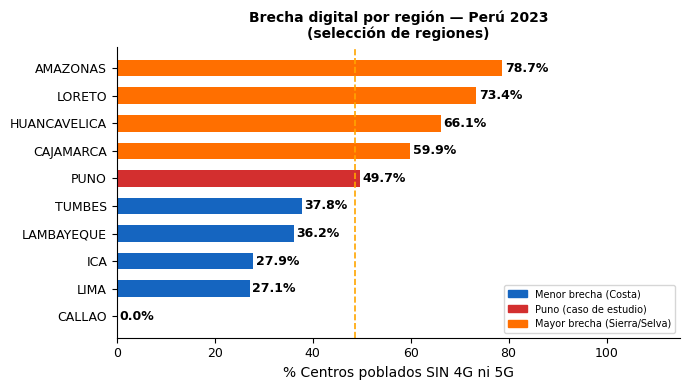

Figura guardada en alta resolución


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Seleccionar regiones clave: top 5 mejor + Puno + top 5 peor
regiones_clave = [
    'CALLAO', 'LIMA', 'ICA', 'LAMBAYEQUE', 'TUMBES',  # mejores
    'PUNO',                                              # caso estudio
    'CAJAMARCA', 'HUANCAVELICA', 'LORETO', 'AMAZONAS'  # peores
]

brecha_fig = brecha[brecha['DEPARTAMENTO'].isin(regiones_clave)].copy()
brecha_fig = brecha_fig.sort_values('pct_brecha', ascending=True)

# Colores
colores = []
for d in brecha_fig['DEPARTAMENTO']:
    if d == 'PUNO':
        colores.append('#d32f2f')
    elif d in ['CALLAO','LIMA','ICA','LAMBAYEQUE','TUMBES']:
        colores.append('#1565C0')
    else:
        colores.append('#FF6F00')

fig, ax = plt.subplots(figsize=(7, 4))  # tamaño doble columna
bars = ax.barh(brecha_fig['DEPARTAMENTO'], brecha_fig['pct_brecha'],
               color=colores, height=0.6)

# Etiquetas
for bar, val in zip(bars, brecha_fig['pct_brecha']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# Línea promedio nacional
prom = brecha_valida['pct_brecha'].mean()
print(f"Promedio: {prom:.1f}%")  # debe dar ~48.7%
ax.axvline(x=prom, color='orange', linestyle='--', linewidth=1.2,
           label=f'Promedio nacional: {prom:.1f}%')

# Leyenda
p1 = mpatches.Patch(color='#1565C0', label='Menor brecha (Costa)')
p2 = mpatches.Patch(color='#d32f2f', label='Puno (caso de estudio)')
p3 = mpatches.Patch(color='#FF6F00', label='Mayor brecha (Sierra/Selva)')
ax.legend(handles=[p1, p2, p3],
          loc='lower right', fontsize=7, framealpha=0.8)

ax.set_xlabel('% Centros poblados SIN 4G ni 5G', fontsize=10)
ax.set_title('Brecha digital por región — Perú 2023\n(selección de regiones)',
             fontsize=10, fontweight='bold')
ax.set_xlim(0, 115)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_brecha_puno_compacta.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura guardada en alta resolución")

In [ ]:
print("=== VERIFICACIÓN TABLA 1 ===")
print(f"Total CCPP únicos: {ccpp['UBIGEO_CCPP'].nunique():,}")
print(f"\nDistribución max_tech:")
print(ccpp['max_tech'].value_counts())
print(f"\nTotal registros dataset: {len(df):,}")
print(f"\nDistribución nivel_tecnologico (con duplicados):")
print(df['nivel_tecnologico'].value_counts())

=== VERIFICACIÓN TABLA 1 ===
Total CCPP únicos: 31,439

Distribución max_tech:
max_tech
4G    15470
3G    12754
2G     3250
5G       29
Name: count, dtype: int64

Total registros dataset: 51,366

Distribución nivel_tecnologico (con duplicados):
nivel_tecnologico
4G    23022
3G    22012
2G     6302
5G       30
Name: count, dtype: int64


In [ ]:
print(f"Brecha real (CCPP únicos):")
print(f"Sin 4G/5G: {(ccpp['tiene_4G_5G']==0).sum():,}")
print(f"Con 4G/5G: {ccpp['tiene_4G_5G'].sum():,}")
print(f"% Brecha: {(ccpp['tiene_4G_5G']==0).mean()*100:.1f}%")
print(f"% Cobertura: {ccpp['tiene_4G_5G'].mean()*100:.1f}%")

Brecha real (CCPP únicos):
Sin 4G/5G: 16,004
Con 4G/5G: 15,499
% Brecha: 50.8%
% Cobertura: 49.2%


moran


In [ ]:
import geopandas as gpd
from pysal.explore import esda
from pysal.lib import weights

# Obtener coordenadas Y departamento desde df original
coords = df.groupby('UBIGEO_CCPP').agg(
    LATITUD=('LATITUD', 'first'),
    LONGITUD=('LONGITUD', 'first'),
    DEPARTAMENTO=('DEPARTAMENTO', 'first')
).reset_index()

# Ver columnas disponibles en ccpp
print("Columnas en ccpp:", ccpp.columns.tolist())

# Unir con ccpp
ccpp_geo = ccpp.merge(coords, on='UBIGEO_CCPP', how='left')

# Eliminar filas sin coordenadas
ccpp_geo = ccpp_geo.dropna(subset=['LATITUD', 'LONGITUD'])

# Crear GeoDataFrame
gdf_ccpp = gpd.GeoDataFrame(
    ccpp_geo,
    geometry=gpd.points_from_xy(ccpp_geo['LONGITUD'], ccpp_geo['LATITUD']),
    crs='EPSG:4326'
)

print(f"\nGeoDataFrame creado: {len(gdf_ccpp):,} centros poblados")
print(f"Columnas: {gdf_ccpp.columns.tolist()}")
print(gdf_ccpp.head(2))

Columnas en ccpp: ['DEPARTAMENTO', 'UBIGEO_CCPP', 'tiene_4G_5G', 'max_tech', 'zona']

GeoDataFrame creado: 31,503 centros poblados
Columnas: ['DEPARTAMENTO_x', 'UBIGEO_CCPP', 'tiene_4G_5G', 'max_tech', 'zona', 'LATITUD', 'LONGITUD', 'DEPARTAMENTO_y', 'geometry']
  DEPARTAMENTO_x  UBIGEO_CCPP  tiene_4G_5G max_tech   zona   LATITUD  \
0       AMAZONAS    101010001            1       4G  Selva -6.229414   
1       AMAZONAS    101010002            0       3G  Selva -6.202440   

    LONGITUD DEPARTAMENTO_y                    geometry  
0 -77.872497       AMAZONAS   POINT (-77.8725 -6.22941)  
1 -77.901470       AMAZONAS  POINT (-77.90147 -6.20244)  


In [ ]:
# Renombrar para limpiar
gdf_ccpp = gdf_ccpp.rename(columns={'DEPARTAMENTO_x': 'DEPARTAMENTO'})
gdf_ccpp = gdf_ccpp.drop(columns=['DEPARTAMENTO_y'])

print(f"CCPP con coordenadas: {len(gdf_ccpp):,}")
print(f"CCPP sin coordenadas: {31439 - len(gdf_ccpp):,}")

# ── Índice de Moran Global ──────────────────────────────
w = weights.KNN.from_dataframe(gdf_ccpp, k=5)
w.transform = 'r'

moran = esda.Moran(gdf_ccpp['tiene_4G_5G'], w)

print("\n" + "=" * 50)
print("ÍNDICE DE MORAN — AUTOCORRELACIÓN ESPACIAL")
print("=" * 50)
print(f"Moran I:    {moran.I:.4f}")
print(f"p-valor:    {moran.p_sim:.4f}")
print(f"z-score:    {moran.z_norm:.4f}")
print(f"Esperado:   {moran.EI:.4f}")

if moran.p_sim < 0.05:
    if moran.I > 0:
        print("\n✅ Autocorrelación POSITIVA significativa")
        print("→ Los CCPP con cobertura 4G/5G se agrupan")
        print("  espacialmente con otros de igual cobertura")
    else:
        print("\n⚠️ Autocorrelación NEGATIVA significativa")
else:
    print("\n❌ No hay autocorrelación espacial significativa")

# ── Moran Local (LISA) ──────────────────────────────────
moran_loc = esda.Moran_Local(gdf_ccpp['tiene_4G_5G'], w)
gdf_ccpp['moran_q'] = moran_loc.q
gdf_ccpp['moran_p'] = moran_loc.p_sim
gdf_ccpp['lisa_sig'] = moran_loc.p_sim < 0.05

# Clasificar clusters
labels = {1:'HH', 2:'LH', 3:'LL', 4:'HL'}
gdf_ccpp['cluster'] = gdf_ccpp['moran_q'].map(labels)
gdf_ccpp.loc[~gdf_ccpp['lisa_sig'], 'cluster'] = 'No sig.'

print("\n=== CLUSTERS LISA SIGNIFICATIVOS ===")
print(gdf_ccpp[gdf_ccpp['lisa_sig']]['cluster'].value_counts())
print("\nHH = zona con 4G rodeada de 4G (clúster favorable)")
print("LL = zona sin 4G rodeada de sin 4G (clúster de exclusión)")
print("HL = zona con 4G rodeada de sin 4G (outlier positivo)")
print("LH = zona sin 4G rodeada de con 4G (outlier negativo)")

CCPP con coordenadas: 31,503
CCPP sin coordenadas: -64

ÍNDICE DE MORAN — AUTOCORRELACIÓN ESPACIAL
Moran I:    0.4692
p-valor:    0.0010
z-score:    141.2463
Esperado:   -0.0000

✅ Autocorrelación POSITIVA significativa
→ Los CCPP con cobertura 4G/5G se agrupan
  espacialmente con otros de igual cobertura

=== CLUSTERS LISA SIGNIFICATIVOS ===
cluster
LL    6453
HH    6211
LH    2113
HL    1226
Name: count, dtype: int64

HH = zona con 4G rodeada de 4G (clúster favorable)
LL = zona sin 4G rodeada de sin 4G (clúster de exclusión)
HL = zona con 4G rodeada de sin 4G (outlier positivo)
LH = zona sin 4G rodeada de con 4G (outlier negativo)


In [ ]:
print("=== CLUSTERS LISA SIGNIFICATIVOS ===")
print(gdf_ccpp[gdf_ccpp['lisa_sig']]['cluster'].value_counts())
print(f"\nTotal CCPP significativos: {gdf_ccpp['lisa_sig'].sum():,}")
print(f"% del total: {gdf_ccpp['lisa_sig'].mean()*100:.1f}%")

print("\n=== CLUSTERS POR ZONA ===")
print(gdf_ccpp[gdf_ccpp['lisa_sig']].groupby(['zona','cluster']).size().unstack(fill_value=0))

print("\n=== CLUSTERS POR DEPARTAMENTO (top 10) ===")
print(gdf_ccpp[gdf_ccpp['lisa_sig'] & gdf_ccpp['cluster'].isin(['LL'])].groupby('DEPARTAMENTO').size().sort_values(ascending=False).head(10))

=== CLUSTERS LISA SIGNIFICATIVOS ===
cluster
LL    6453
HH    6211
LH    2113
HL    1226
Name: count, dtype: int64

Total CCPP significativos: 16,003
% del total: 50.8%

=== CLUSTERS POR ZONA ===
cluster    HH   HL    LH    LL
zona                          
Costa    2477  313   578   858
Otro        0    2    13    26
Selva     409  170   186  1026
Sierra   3325  741  1336  4543

=== CLUSTERS POR DEPARTAMENTO (top 10) ===
DEPARTAMENTO
ANCASH          741
PUNO            624
CAJAMARCA       608
AMAZONAS        545
CUSCO           538
HUANCAVELICA    487
HUANUCO         461
AYACUCHO        407
JUNIN           330
SAN MARTIN      320
dtype: int64


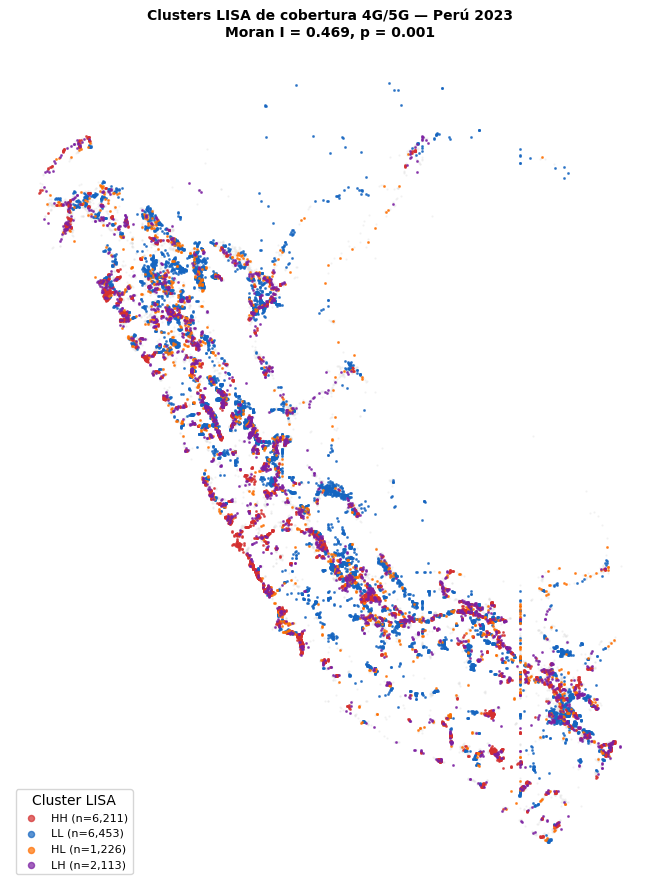

Figura LISA guardada


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Filtrar solo significativos
gdf_sig = gdf_ccpp[gdf_ccpp['lisa_sig']].copy()
gdf_no_sig = gdf_ccpp[~gdf_ccpp['lisa_sig']].copy()

colores_cluster = {
    'HH': '#d32f2f',   # rojo — inclusión agrupada
    'LL': '#1565C0',   # azul — exclusión agrupada
    'HL': '#FF6F00',   # naranja — outlier positivo
    'LH': '#7B1FA2',   # morado — outlier negativo
}

fig, ax = plt.subplots(figsize=(7, 9))

# Puntos no significativos
gdf_no_sig.plot(ax=ax, color='#E0E0E0', markersize=0.3, alpha=0.4)

# Clusters significativos
for cluster, color in colores_cluster.items():
    subset = gdf_sig[gdf_sig['cluster'] == cluster]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=1.2,
                   alpha=0.7, label=f'{cluster} (n={len(subset):,})')

ax.set_title('Clusters LISA de cobertura 4G/5G — Perú 2023\n'
             f'Moran I = 0.469, p = 0.001',
             fontsize=10, fontweight='bold')
ax.set_axis_off()
ax.legend(title='Cluster LISA', fontsize=8,
          loc='lower left', markerscale=4)

plt.tight_layout()
plt.savefig('fig4_clusters_lisa.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura LISA guardada")